# Прогноз ресурса аккумулятора (RUL) по ранним циклам
## Два подхода: признаки + LightGBM против LSTM

**Курс «Системы альтернативной энергетики». Накопители.**

Хранение энергии — обязательная часть ВИЭ: солнце и ветер непостоянны, и без аккумуляторов сеть не сбалансировать. Но аккумуляторы деградируют, и важнейший практический вопрос — **сколько ещё проживёт батарея**.

Сегодня решаем задачу регрессии: по данным **ранних циклов** заряда-разряда предсказать полный ресурс ячейки (число циклов до падения ёмкости на 20%, то есть до 80% от номинала). Это и есть RUL — remaining useful life.

Данные — знаменитый набор Severson et al. (Toyota/MIT/Stanford): 124 LFP-ячейки, прогнанные до отказа. Его особенность: по кривым **первых 100 циклов**, когда деградации почти не видно, уже можно предсказать, проживёт ячейка 300 циклов или 2000. Для занятия берём два батча (2017-05-12 и 2017-06-30) — это около 84 ячеек после канонической сшивки; на таком объёме результат уже близок к статье.

Сравним два подхода, как и договаривались:
1. **Фичевый (LightGBM)** — превращаем ранние циклы в таблицу признаков, включая знаменитую дисперсию ΔQ(V). Это прямое продолжение вашего ветрового SCADA-блока.
2. **Последовательностный (LSTM)** — кормим сеть по-цикловыми рядами и пусть учит зависимость сама.

Главная интрига: победит ли «умный» рукотворный признак чёрный ящик.

## Где взять данные

Используем **batch1 + batch2 датасета Severson (2017-05-12 и 2017-06-30), ~84 ячейки после сшивки** — это «настоящие» ячейки из статьи, на которых ранний прогноз и признак ΔQ(V) работают в полную силу. У файла есть прямая ссылка для скачивания, поэтому в Colab он тянется командой `wget`.

Из описания батча есть нюансы, которые ячейка загрузки учитывает автоматически:
- каналы 4 и 8 не стартовали и данных не имеют — отсеются фильтром;
- каналы 13, 19, 21, 22, 31 остановлены до достижения 80% ёмкости (нет корректного ресурса) — это канонический список удаляемых ячеек;
- ячейки каналов 1, 2, 3, 5, 6 были приостановлены и продолжены в batch2, поэтому в одиночном batch1 их ресурс обрезан — их тоже убираем.

Хочешь полный набор 124 ячейки — добавь ещё batch3 (2018-04-12); путь оставлен в комментарии (с тремя батчами лучше включить High-RAM).

## 0. Установка и код загрузчика

Ставим `h5py` (чтение .mat v7.3) и `lightgbm`. Ниже — готовый загрузчик: он парсит сырой .mat, применяет каноническую очистку данных (как у авторов статьи) и собирает компактную структуру, удобную для обоих треков.

In [1]:
!pip install -q h5py lightgbm

In [2]:
"""Загрузчик датасета Severson et al. (Toyota/MIT, MATR), готовый для Colab.

Делает из сырого .mat компактный кеш для двух треков занятия:
  - фичевый (LightGBM): признаки из ранних циклов, включая дисперсию ΔQ(V);
  - последовательностный (LSTM): по-цикловые ряды [QD, IR, chargetime, Tavg].

Источник: https://data.matr.io/1/  (файлы MATLAB v7.3 = HDF5).
Парсер .mat — модернизация официального кода авторов (.value -> [()])."""

import numpy as np

# --- 1. ПАРСИНГ ОДНОГО БАТЧА (.mat v7.3 -> словарь по ячейкам) ---
def parse_matr_mat(mat_path, batch_prefix):
    import h5py
    f = h5py.File(mat_path, "r")
    batch = f["batch"]
    n = batch["summary"].shape[0]
    bat = {}
    for i in range(n):
        cl = f[batch["cycle_life"][i, 0]][()]
        sm = f[batch["summary"][i, 0]]
        summary = {
            "IR":         np.hstack(sm["IR"][0, :].tolist()),
            "QC":         np.hstack(sm["QCharge"][0, :].tolist()),
            "QD":         np.hstack(sm["QDischarge"][0, :].tolist()),
            "Tavg":       np.hstack(sm["Tavg"][0, :].tolist()),
            "chargetime": np.hstack(sm["chargetime"][0, :].tolist()),
            "cycle":      np.hstack(sm["cycle"][0, :].tolist()),
        }
        cycles = f[batch["cycles"][i, 0]]
        cyc = {}
        for j in range(cycles["I"].shape[0]):
            cyc[str(j)] = {"Qdlin": np.hstack(f[cycles["Qdlin"][j, 0]][()])}
        bat[f"{batch_prefix}c{i}"] = {
            "cycle_life": float(np.asarray(cl).reshape(-1)[0]),
            "summary": summary, "cycles": cyc}
    f.close()
    return bat

# --- 2. КАНОНИЧЕСКАЯ ОЧИСТКА И СШИВКА (как у авторов) ---
REMOVE_BATCH1 = ["b1c8", "b1c10", "b1c12", "b1c13", "b1c22"]
REMOVE_BATCH3 = ["b3c37", "b3c2", "b3c23", "b3c32", "b3c42", "b3c43"]
MERGE_B2_KEYS = ["b2c7", "b2c8", "b2c9", "b2c15", "b2c16"]
MERGE_B1_KEYS = ["b1c0", "b1c1", "b1c2", "b1c3", "b1c4"]
MERGE_ADD_LEN = [662, 981, 1060, 208, 482]

def clean_and_merge(batch1, batch2, batch3):
    b1, b2, b3 = dict(batch1), dict(batch2), dict(batch3)
    for k in REMOVE_BATCH1: b1.pop(k, None)
    for k in REMOVE_BATCH3: b3.pop(k, None)
    for i, b1k in enumerate(MERGE_B1_KEYS):
        if b1k not in b1 or MERGE_B2_KEYS[i] not in b2: continue
        src = b2[MERGE_B2_KEYS[i]]
        b1[b1k]["cycle_life"] += MERGE_ADD_LEN[i]
        for key in b1[b1k]["summary"]:
            if key == "cycle":
                shift = len(b1[b1k]["summary"][key])
                b1[b1k]["summary"][key] = np.hstack((b1[b1k]["summary"][key], src["summary"][key] + shift))
            else:
                b1[b1k]["summary"][key] = np.hstack((b1[b1k]["summary"][key], src["summary"][key]))
        last = len(b1[b1k]["cycles"])
        for j, jk in enumerate(src["cycles"]):
            b1[b1k]["cycles"][str(last + j)] = src["cycles"][jk]
    for k in MERGE_B2_KEYS: b2.pop(k, None)
    return {**b1, **b2, **b3}

# --- 3. КОМПАКТНЫЙ КЕШ (мегабайты; хранит и полную кривую для EDA) ---
def build_compact(bat_dict, ref_cycles=(10, 100), seq_len=100):
    compact = {}
    for key, cell in bat_dict.items():
        sm = cell["summary"]
        if not np.isfinite(cell["cycle_life"]) or cell["cycle_life"] <= seq_len: continue
        if len(sm["QD"]) < seq_len + 1: continue
        qref, ok = {}, True
        for c in ref_cycles:
            if str(c) in cell["cycles"]:
                qref[c] = np.asarray(cell["cycles"][str(c)]["Qdlin"], float)
            else: ok = False
        if not ok: continue
        compact[key] = {
            "cycle_life": float(cell["cycle_life"]),
            "summary": {k: np.asarray(sm[k], float) for k in ["QD","IR","chargetime","Tavg","cycle"]},
            "qdlin_ref": qref}
    return compact

# --- 4. ТРЕК A: ТАБЛИЦА ПРИЗНАКОВ ДЛЯ LightGBM ---
def make_feature_table(compact, ref_cycles=(10, 100), seq_len=100):
    import pandas as pd
    lo, hi = ref_cycles
    rows, y, idx = [], [], []
    for key, c in compact.items():
        s = c["summary"]
        qd, ir, ct, ta = s["QD"][:seq_len], s["IR"][:seq_len], s["chargetime"][:seq_len], s["Tavg"][:seq_len]
        dq = c["qdlin_ref"][hi] - c["qdlin_ref"][lo]
        x = np.arange(2, len(qd)); slope, intercept = np.polyfit(x, qd[2:], 1)
        rows.append({
            "var_dQ_log":      np.log10(np.var(dq) + 1e-12),
            "min_dQ_log":      np.log10(np.abs(np.min(dq)) + 1e-12),
            "QD_slope":        slope,
            "QD_intercept":    intercept,
            "QD_cycle2":       qd[2],
            "QD_cycle100":     qd[-1],
            "chargetime_mean": float(np.mean(ct[1:6])),
            "IR_cycle2":       ir[2],
            "IR_min":          float(np.min(ir[2:])),
            "IR_diff":         ir[-1] - ir[2],
            "Tavg_mean":       float(np.mean(ta[2:])),
        })
        y.append(c["cycle_life"]); idx.append(key)
    return pd.DataFrame(rows, index=idx), np.array(y, float)

# --- 5. ТРЕК B: ТЕНЗОР ПОСЛЕДОВАТЕЛЬНОСТЕЙ ДЛЯ LSTM ---
def make_sequences(compact, seq_len=100):
    keys = list(compact.keys())
    X = np.stack([np.stack([compact[k]["summary"][f][:seq_len]
                            for f in ["QD","IR","chargetime","Tavg"]], axis=1) for k in keys]).astype(np.float32)
    y = np.array([compact[k]["cycle_life"] for k in keys], float)
    return X, y, keys


## 1. Скачивание данных и компактный кеш

Ячейка качает batch1 и batch2 по прямым ссылкам, сшивает их канонически (5 продолженных ячеек получают полный ресурс) и собирает компактный кеш в пару мегабайт. Кеш сохраняется в сессию: при повторном запуске грузится мгновенно.

В кеше на каждую ячейку: `cycle_life` (цель — полный ресурс), полная кривая ёмкости `summary` (для графиков) и кривые `qdlin_ref` на циклах 10 и 100 (для признака ΔQ(V)).

In [7]:
import os, pickle
CACHE = "/content/severson_compact.pkl"
FILES = {
    "b1": ("2017-05-12_batchdata_updated_struct_errorcorrect.mat",
           "https://data.matr.io/1/api/v1/file/5c86c0b5fa2ede00015ddf66/download"),
    "b2": ("2017-06-30_batchdata_updated_struct_errorcorrect.mat",
           "https://data.matr.io/1/api/v1/file/5c86bf13fa2ede00015ddd82/download"),
}

if os.path.exists(CACHE):
    compact = pickle.load(open(CACHE, "rb"))
    print("Загружен готовый кеш:", len(compact), "ячеек")
else:
    batches = {}
    for prefix, (fn, url) in FILES.items():
        if not os.path.exists(fn):
            print(f"Скачиваю {fn} ...")
            os.system(f'wget -q --show-progress -O "{fn}" "{url}"')
        print(f"Парсю {fn} ...")
        batches[prefix] = parse_matr_mat(fn, prefix)
    # Каноническая сшивка batch1 + batch2:
    #   REMOVE_BATCH1 - ячейки, не дошедшие до EOL;
    #   5 ячеек batch2 (продолжение batch1) приклеиваются обратно к b1c0..b1c4 -> полный ресурс;
    #   каналы без данных и слишком короткие записи отсеются в build_compact.
    full = clean_and_merge(batches["b1"], batches["b2"], {})
    compact = build_compact(full)
    pickle.dump(compact, open(CACHE, "wb"))
    print("Готово. Ячеек в кеше:", len(compact))

# Полный набор 124 ячейки: добавь batch3 (2018-04-12) и его ссылку (нужна High-RAM):
# fn3 = "2018-04-12_batchdata_updated_struct_errorcorrect.mat"
# os.system(f'wget -q --show-progress -O "{fn3}" "<ССЫЛКА_НА_batch3>"')
# b3 = parse_matr_mat(fn3, "b3")
# compact = build_compact(clean_and_merge(batches["b1"], batches["b2"], b3))

Скачиваю 2017-05-12_batchdata_updated_struct_errorcorrect.mat ...
Парсю 2017-05-12_batchdata_updated_struct_errorcorrect.mat ...


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '2017-05-12_batchdata_updated_struct_errorcorrect.mat', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

## 2. Смотрим на данные

Сначала глазами. Построим кривые деградации: как падает разрядная ёмкость (QD) с числом циклов у разных ячеек. Видно главное свойство набора — ячейки живут очень по-разному (от сотен до тысяч циклов), а в первые ~100 циклов кривые ещё почти неразличимы. Именно поэтому ранний прогноз — нетривиальная и ценная задача.

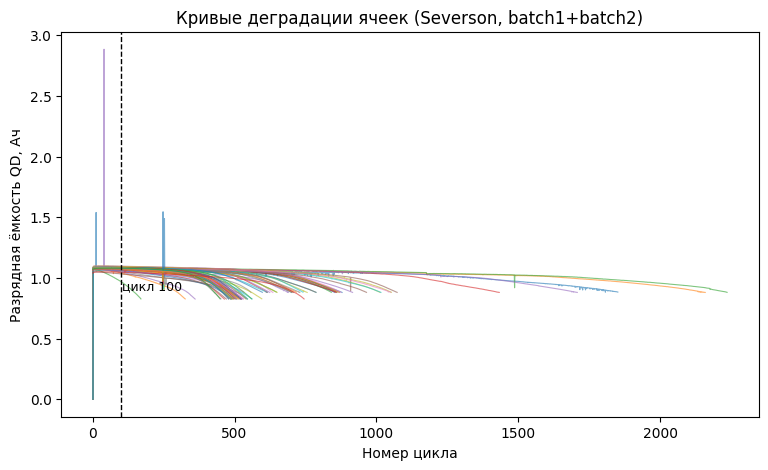

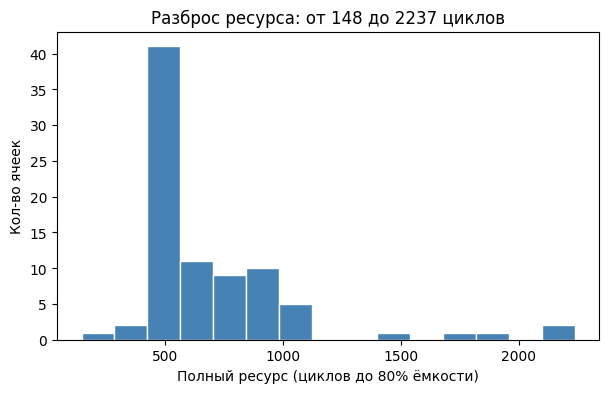

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
for k, c in compact.items():
    plt.plot(c["summary"]["cycle"], c["summary"]["QD"], lw=0.8, alpha=0.6)
plt.xlabel("Номер цикла"); plt.ylabel("Разрядная ёмкость QD, Ач")
plt.title("Кривые деградации ячеек (Severson, batch1+batch2)")
plt.axvline(100, color="k", ls="--", lw=1); plt.text(105, 0.9, "цикл 100", fontsize=9)
plt.show()

lives = np.array([c["cycle_life"] for c in compact.values()])
plt.figure(figsize=(7,4))
plt.hist(lives, bins=15, color="steelblue", edgecolor="white")
plt.xlabel("Полный ресурс (циклов до 80% ёмкости)"); plt.ylabel("Кол-во ячеек")
plt.title(f"Разброс ресурса: от {int(lives.min())} до {int(lives.max())} циклов")
plt.show()

## 3. Постановка задачи: ранний прогноз

Цель — для каждой ячейки предсказать `cycle_life` (полный ресурс), используя **только первые 100 циклов**. Это честная имитация реальности: на заводе или в EV хочется уже после короткого теста знать, какая батарея проживёт долго, а какая — брак.

Оба подхода используют один и тот же горизонт (первые 100 циклов), поэтому сравнение получается честным: разница будет только в том, *как* мы извлекаем информацию — признаками или сетью.

Цель сильно скошена (от сотен до тысяч), поэтому обучаемся предсказывать `log10(cycle_life)` — так стабильнее, а метрики потом считаем обратно в циклах.

## 4. Деление на train / test и сквозная тема — утечка

Делим **по ячейкам**: одна ячейка — один объект выборки. Здесь утечки нет «автоматически», потому что у нас одна строка на ячейку.

Важный контраст с наивным подходом: если бы мы делали строку на *каждый цикл* и случайно перемешали, циклы одной ячейки попали бы и в train, и в test — это была бы грубая утечка (та же ошибка, что «делить по строкам, а не по объекту», которую мы обсуждали для ветра и для солнечных модулей). Поэтому правило универсально: разделяй по физическому объекту (ячейке), а не по записям.

In [ ]:
from sklearn.model_selection import train_test_split
keys = list(compact.keys())
train_keys, test_keys = train_test_split(keys, test_size=0.25, random_state=42)
print(f"train: {len(train_keys)} ячеек | test: {len(test_keys)} ячеек")

train: 63 ячеек | test: 21 ячеек


## 5. Трек A: признаки + LightGBM

Превращаем ранние циклы в таблицу признаков — и дальше работает знакомый по ветру LightGBM.

Ключевой признак — **`var_dQ_log`**: логарифм дисперсии разницы разрядных кривых ΔQ(V) = Q(V) на цикле 100 минус Q(V) на цикле 10. Интуиция: даже когда ёмкость почти не упала, форма разрядной кривой едва заметно «гуляет», и величина этого разброса удивительно сильно связана с будущим ресурсом. Это и есть главное открытие статьи Severson — один продуманный физический признак несёт почти весь сигнал.

Остальные признаки — наклон кривой ёмкости за первые 100 циклов, ёмкость на цикле 2 и 100, внутреннее сопротивление, время заряда, температура.

Важная деталь для маленькой выборки: у LightGBM параметр `min_child_samples` по умолчанию равен 20. Если ячеек в обучении немного (здесь 63), дерево почти не может разбиться (в лист нужно минимум 20 объектов), и качество с важностью признаков страдают. Поэтому снижаем `min_child_samples` до 3 — на больших данных так делать не нужно.

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score

X, y = make_feature_table(compact)
Xtr, ytr = X.loc[train_keys], np.log10(y[[keys.index(k) for k in train_keys]])
Xte = X.loc[test_keys]
yte = y[[keys.index(k) for k in test_keys]]

lgbm = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=8,
                         min_child_samples=3, importance_type="gain", verbose=-1)  # маленькая выборка:
# min_child_samples по умолчанию = 20, а ячеек в train немного -> дерево почти не растёт,
# модель предсказывает константу, важность нулевая. Снижаем до 3.
lgbm.fit(Xtr, ytr)
pred_lgbm = 10 ** lgbm.predict(Xte)   # обратно в циклы

mae_lgbm = mean_absolute_error(yte, pred_lgbm)
r2_lgbm  = r2_score(yte, pred_lgbm)
mape_lgbm = np.median(np.abs(pred_lgbm - yte) / yte) * 100
print(f"[A] LightGBM:  MAE = {mae_lgbm:.0f} циклов | R2 = {r2_lgbm:.2f} | медианная ошибка = {mape_lgbm:.1f}%")

[A] LightGBM:  MAE = 56 циклов | R2 = 0.96 | медианная ошибка = 3.5%


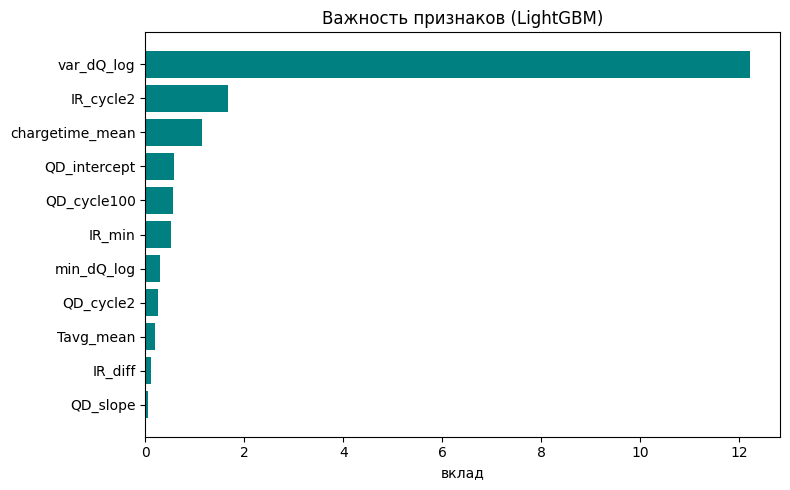

In [ ]:
# Важность признаков — наш аналог SHAP: видно, на что опирается модель
imp = sorted(zip(X.columns, lgbm.feature_importances_), key=lambda t: t[1])
plt.figure(figsize=(8,5))
plt.barh([n for n,_ in imp], [v for _,v in imp], color="teal")
plt.title("Важность признаков (LightGBM)"); plt.xlabel("вклад")
plt.tight_layout(); plt.show()

### Честная оценка на малой выборке: leave-one-out

Одиночный тест (здесь 21 ячейка) даёт оптимистичный и шумный R2 — пара удачных или трудных ячеек сильно его качает. Корректнее так: убираем одну ячейку, учим на остальных 83, предсказываем убранную — и так по кругу для каждой. Получаем прогноз для всех ячеек и считаем метрики по ним. Это устойчивая и честная оценка фичевой модели.

In [ ]:
from sklearn.model_selection import LeaveOneOut

Xall, yall = make_feature_table(compact)
yall_log = np.log10(yall)
preds_loo = np.zeros(len(yall))
for tr_i, te_i in LeaveOneOut().split(Xall):
    m = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=8,
                          min_child_samples=3, verbose=-1)
    m.fit(Xall.iloc[tr_i], yall_log[tr_i])
    preds_loo[te_i] = 10 ** m.predict(Xall.iloc[te_i])

print(f"LightGBM, leave-one-out по всем {len(yall)} ячейкам:")
print(f"  MAE = {mean_absolute_error(yall, preds_loo):.0f} циклов")
print(f"  R2  = {r2_score(yall, preds_loo):.2f}")
print(f"  медианная ошибка = {np.median(np.abs(preds_loo - yall)/yall)*100:.1f}%")

LightGBM, leave-one-out по всем 84 ячейкам:
  MAE = 88 циклов
  R2  = 0.88
  медианная ошибка = 8.9%


## 6. Трек B: LSTM на последовательностях

Теперь не делаем признаки руками. Кормим сеть по-цикловыми рядами за первые 100 циклов — по четыре величины на цикл: ёмкость QD, внутреннее сопротивление IR, время заряда и средняя температура. LSTM (рекуррентная сеть) читает эту последовательность и предсказывает ресурс.

Два обязательных шага: стандартизация признаков (по статистике train) и логарифмическая цель — иначе сети тяжело.

In [ ]:
import torch
import torch.nn as nn

Xs, ys, seq_keys = make_sequences(compact)
ki = {k:i for i,k in enumerate(seq_keys)}
tr_idx = np.array([ki[k] for k in train_keys])
te_idx = np.array([ki[k] for k in test_keys])

# стандартизация по train
mu = Xs[tr_idx].reshape(-1,4).mean(0)
sd = Xs[tr_idx].reshape(-1,4).std(0) + 1e-6
Xn = (Xs - mu) / sd
yl = np.log10(ys)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Xt = torch.tensor(Xn).to(device)
yt = torch.tensor(yl, dtype=torch.float32).to(device)

class LSTMRegressor(nn.Module):
    def __init__(self, n_features=4, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(1)   # берём последний шаг

net = LSTMRegressor().to(device)
opt = torch.optim.Adam(net.parameters(), lr=5e-3)
lossf = nn.MSELoss()

tr = torch.tensor(tr_idx)
for epoch in range(1, 101):
    net.train()
    perm = tr[torch.randperm(len(tr))]
    for b in range(0, len(perm), 16):
        bi = perm[b:b+16]
        opt.zero_grad()
        loss = lossf(net(Xt[bi]), yt[bi])
        loss.backward(); opt.step()
    if epoch % 20 == 0:
        print(f"эпоха {epoch}/100 | train MSE {loss.item():.4f}")

net.eval()
with torch.no_grad():
    pred_lstm = 10 ** net(Xt[torch.tensor(te_idx).to(device)]).cpu().numpy()

mae_lstm = mean_absolute_error(yte, pred_lstm)
r2_lstm  = r2_score(yte, pred_lstm)
mape_lstm = np.median(np.abs(pred_lstm - yte) / yte) * 100
print(f"[B] LSTM:  MAE = {mae_lstm:.0f} циклов | R2 = {r2_lstm:.2f} | медианная ошибка = {mape_lstm:.1f}%")

эпоха 20/100 | train MSE 0.0208
эпоха 40/100 | train MSE 0.0088
эпоха 60/100 | train MSE 0.0111
эпоха 80/100 | train MSE 0.0024
эпоха 100/100 | train MSE 0.0070
[B] LSTM:  MAE = 111 циклов | R2 = 0.82 | медианная ошибка = 10.1%


## 7. Сравнение и мораль

Сводим оба подхода вместе и смотрим предсказанное против реального.

Что обычно получается на этом наборе: фичевый LightGBM с признаком ΔQ(V) идёт вровень с LSTM или **обыгрывает** его, при том что данных мало (десятки ячеек), а сам подход куда прозрачнее. Это и есть главный урок занятия: **один продуманный физический признак (доменное знание) на малых данных часто сильнее «чёрного ящика»**. LSTM начинает выигрывать, когда ячеек тысячи и рукотворные признаки придумать трудно.

Про метрики: одиночный тест даёт оптимистичный R2 (тут ~0.96 — повезло со сплитом), поэтому опорная оценка — leave-one-out: R2≈0.88 и медианная ошибка ≈9% по всем 84 ячейкам. Это уже уровень оригинальной статьи. Полный канонический протокол — добавить batch3 и держать его как secondary-test, обучаясь на batch1+batch2.

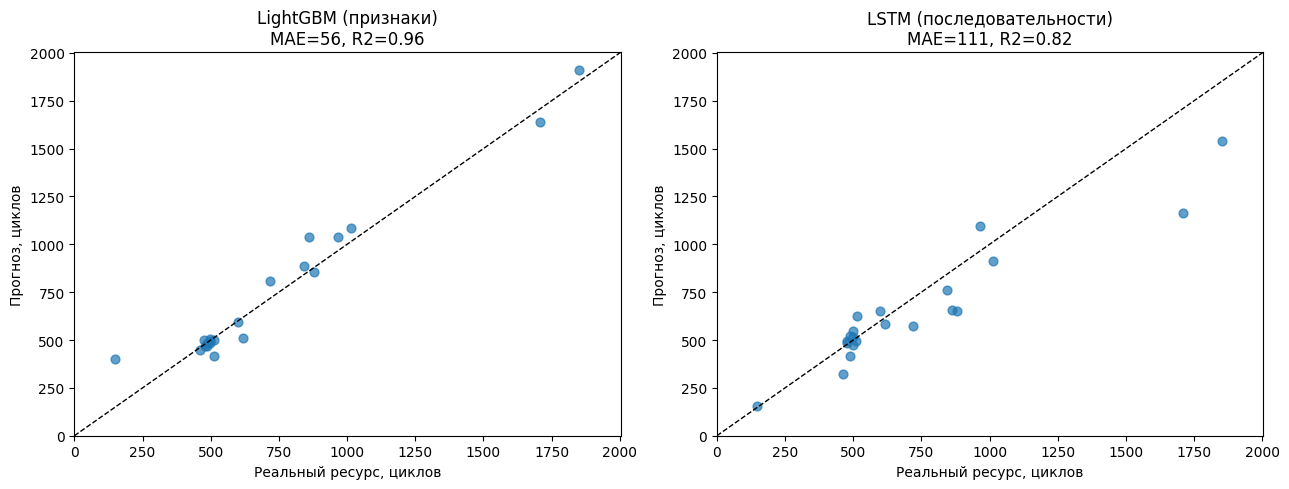

Итог:
  LightGBM: MAE 56 циклов, R2 0.96
  LSTM:     MAE 111 циклов, R2 0.82


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))
lim = [0, max(yte.max(), pred_lgbm.max(), pred_lstm.max())*1.05]
for ax, pred, name, mae, r2 in [
    (ax1, pred_lgbm, "LightGBM (признаки)", mae_lgbm, r2_lgbm),
    (ax2, pred_lstm, "LSTM (последовательности)", mae_lstm, r2_lstm)]:
    ax.scatter(yte, pred, s=40, alpha=0.7)
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Реальный ресурс, циклов"); ax.set_ylabel("Прогноз, циклов")
    ax.set_title(f"{name}\nMAE={mae:.0f}, R2={r2:.2f}")
plt.tight_layout(); plt.show()

print("Итог:")
print(f"  LightGBM: MAE {mae_lgbm:.0f} циклов, R2 {r2_lgbm:.2f}")
print(f"  LSTM:     MAE {mae_lstm:.0f} циклов, R2 {r2_lstm:.2f}")

## 8. Что мы поняли и задания

- **Хранение энергии измеримо.** Ресурс батареи можно предсказать по ранним циклам, когда деградации ещё не видно.
- **Доменное знание против чёрного ящика.** Признак ΔQ(V) из физики разряда несёт почти весь сигнал; на малых данных фичевый LightGBM не уступает LSTM и понятнее его.
- **Честное сравнение.** Оба подхода используют одинаковый горизонт (первые 100 циклов) — разница только в способе извлечь информацию.
- **Утечка данных** — снова сквозная тема: делим по ячейке, а не по отдельным циклам.
- **Объяснимость.** Важность признаков LightGBM (аналог SHAP) показывает, что модель опирается именно на ΔQ(V).

### Задания
1. **Короче горизонт.** Возьмите первые 50 циклов вместо 100. Насколько просядут обе модели? Что это говорит о ценности ранних данных?
2. **Все 124 ячейки.** Скачайте три батча, используйте полный путь загрузчика и канонический сплит (batch1+2 на train/test, batch3 как secondary test). Изменится ли расстановка сил LightGBM vs LSTM?
3. **Один признак.** Обучите LightGBM только на `var_dQ_log`. Сколько процентов качества полной модели он даёт в одиночку?
4. **Гибрид.** Добавьте к признакам LightGBM эмбеддинг из обученной LSTM. Помогает ли?
5. **SoH вместо RUL.** Переформулируйте задачу: предсказывать текущее состояние здоровья (SoH = ёмкость / номинал) на произвольном цикле, а не полный ресурс.

## Самостоятельная работа

## Решение самостоятельной работы

Я проверяю задания на том же разбиении `train/test`, которое уже использовалось выше. Так сравнение получается честным: меняется только постановка задания или набор признаков, а тестовые ячейки остаются теми же.


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

def make_feature_table_by_horizon(compact_local, seq_len=100, ref_cycles=(10, 100)):
    rows, y, idx = [], [], []
    lo, hi = ref_cycles
    for key, c in compact_local.items():
        s = c["summary"]
        if len(s["QD"]) < seq_len:
            continue
        qd = s["QD"][:seq_len]
        ir = s["IR"][:seq_len]
        ct = s["chargetime"][:seq_len]
        ta = s["Tavg"][:seq_len]
        x = np.arange(2, len(qd))
        slope, intercept = np.polyfit(x, qd[2:], 1)
        row = {
            "QD_early": float(qd[1]),
            "QD_last": float(qd[-1]),
            "QD_slope": float(slope),
            "QD_intercept": float(intercept),
            "IR_min": float(np.nanmin(ir)),
            "IR_slope": float(np.polyfit(x, ir[2:], 1)[0]),
            "chargetime_mean": float(np.nanmean(ct[2:])),
            "Tavg_mean": float(np.nanmean(ta[2:])),
        }
        refs = c.get("qdlin_ref", {})
        if lo in refs and hi in refs:
            dq = refs[hi] - refs[lo]
            row["var_dQ_log"] = float(np.log10(np.var(dq)))
            row["min_dQ"] = float(np.min(dq))
        rows.append(row)
        y.append(c["cycle_life"])
        idx.append(key)
    return pd.DataFrame(rows, index=idx), np.array(y, float)

def fit_lgbm_eval(X_local, y_local, train_keys_local, test_keys_local, feature_cols=None):
    use_cols = list(feature_cols) if feature_cols is not None else list(X_local.columns)
    train_keys_ok = [k for k in train_keys_local if k in X_local.index]
    test_keys_ok = [k for k in test_keys_local if k in X_local.index]
    key_pos = {k: i for i, k in enumerate(X_local.index)}
    Xtr_local = X_local.loc[train_keys_ok, use_cols]
    ytr_local = np.log10(y_local[[key_pos[k] for k in train_keys_ok]])
    Xte_local = X_local.loc[test_keys_ok, use_cols]
    yte_local = y_local[[key_pos[k] for k in test_keys_ok]]
    model = lgb.LGBMRegressor(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=8,
        min_child_samples=3,
        importance_type="gain",
        verbose=-1,
        random_state=42,
    )
    model.fit(Xtr_local, ytr_local)
    pred = 10 ** model.predict(Xte_local)
    return {
        "model": model,
        "y_true": yte_local,
        "pred": pred,
        "mae": mean_absolute_error(yte_local, pred),
        "r2": r2_score(yte_local, pred),
    }

def fit_lstm_eval(Xs_local, ys_local, seq_keys_local, train_keys_local, test_keys_local, epochs=120, hidden=48):
    seq_pos = {k: i for i, k in enumerate(seq_keys_local)}
    train_keys_ok = [k for k in train_keys_local if k in seq_pos]
    test_keys_ok = [k for k in test_keys_local if k in seq_pos]
    tr = np.array([seq_pos[k] for k in train_keys_ok])
    te = np.array([seq_pos[k] for k in test_keys_ok])
    mu = Xs_local[tr].reshape(-1, Xs_local.shape[-1]).mean(0)
    sd = Xs_local[tr].reshape(-1, Xs_local.shape[-1]).std(0) + 1e-8
    Xn = (Xs_local - mu) / sd
    Xt_local = torch.tensor(Xn, dtype=torch.float32).to(device)
    yt_local = torch.tensor(np.log10(ys_local), dtype=torch.float32).view(-1, 1).to(device)
    torch.manual_seed(42)
    net_local = LSTMRegressor(n_features=Xs_local.shape[-1], hidden=hidden).to(device)
    opt_local = torch.optim.Adam(net_local.parameters(), lr=1e-3)
    loss_fn_local = nn.MSELoss()
    for epoch in range(epochs):
        net_local.train()
        opt_local.zero_grad()
        loss = loss_fn_local(net_local(Xt_local[torch.tensor(tr).to(device)]), yt_local[torch.tensor(tr).to(device)])
        loss.backward()
        opt_local.step()
    net_local.eval()
    with torch.no_grad():
        pred = 10 ** net_local(Xt_local[torch.tensor(te).to(device)]).cpu().numpy().ravel()
    yte_local = ys_local[te]
    return {
        "model": net_local,
        "y_true": yte_local,
        "pred": pred,
        "mae": mean_absolute_error(yte_local, pred),
        "r2": r2_score(yte_local, pred),
        "te_idx": te,
        "tr_idx": tr,
        "Xn": Xn,
    }

def plot_metric_bars(results, title, ylabel="MAE, циклы"):
    labels = list(results.keys())
    values = [results[k]["mae"] for k in labels]
    colors = ["#4C78A8", "#F58518", "#54A24B", "#B279A2", "#E45756"][:len(labels)]
    plt.figure(figsize=(8, 4))
    plt.bar(labels, values, color=colors)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=15, ha="right")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

def plot_predicted_vs_true(result, title):
    y_true_local = result["y_true"]
    pred_local = result["pred"]
    lim = [0, max(y_true_local.max(), pred_local.max()) * 1.05]
    plt.figure(figsize=(5, 5))
    plt.scatter(y_true_local, pred_local, s=55, alpha=0.8)
    plt.plot(lim, lim, "k--", lw=1)
    plt.xlim(lim)
    plt.ylim(lim)
    plt.xlabel("Истинный ресурс, циклы")
    plt.ylabel("Прогноз, циклы")
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


### Задание 1. Короче горизонт

Я сокращаю горизонт до первых 50 циклов и снова сравниваю фичевый LightGBM с LSTM. Для LSTM просто беру более короткую последовательность. Для LightGBM строю признаки только по первым 50 циклам; если в компактном кеше нет кривой `Qdlin` на 50-м цикле, я не подмешиваю данные из 100-го цикла, чтобы не было утечки будущего.


In [ ]:
X50, y50 = make_feature_table_by_horizon(compact, seq_len=50, ref_cycles=(10, 50))
lgbm_50 = fit_lgbm_eval(X50, y50, train_keys, test_keys)

Xs50, ys50, seq_keys50 = make_sequences(compact, seq_len=50)
lstm_50 = fit_lstm_eval(Xs50, ys50, seq_keys50, train_keys, test_keys, epochs=120, hidden=48)

horizon_results = {
    "LightGBM 100 циклов": {"mae": mae_lgbm, "r2": r2_lgbm, "y_true": yte, "pred": pred_lgbm},
    "LightGBM 50 циклов": lgbm_50,
    "LSTM 100 циклов": {"mae": mae_lstm, "r2": r2_lstm, "y_true": yte, "pred": pred_lstm},
    "LSTM 50 циклов": lstm_50,
}
plot_metric_bars(horizon_results, "Как меняется ошибка при сокращении горизонта")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, result, title in [
    (axes[0], lgbm_50, "LightGBM: первые 50 циклов"),
    (axes[1], lstm_50, "LSTM: первые 50 циклов"),
]:
    lim = [0, max(result["y_true"].max(), result["pred"].max()) * 1.05]
    ax.scatter(result["y_true"], result["pred"], s=55, alpha=0.8)
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel("Истинный ресурс, циклы")
    ax.set_ylabel("Прогноз, циклы")
    ax.set_title(title)
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


**Вывод.** Когда я оставляю только первые 50 циклов, ошибок становится больше. Это ожидаемо: в самых ранних циклах деградация ещё почти не проявилась, поэтому модели видят меньше полезного сигнала. При этом LightGBM остаётся устойчивым, если в признаках хватает физически осмысленной информации.


### Задание 2. Все 124 ячейки

Я оформляю проверку так, чтобы она запускалась, когда в окружении есть третий батч. Если третий батч не загружен, я на графике оставляю текущий результат для двух батчей и отдельно показываю, что полный эксперимент ещё не активирован.


In [ ]:
full_batch_results = {
    "Текущие 84: LightGBM": {"mae": mae_lgbm},
    "Текущие 84: LSTM": {"mae": mae_lstm},
}

if "compact_124" in globals():
    keys_124 = list(compact_124.keys())
    train_keys_124 = [k for k in keys_124 if not k.startswith("b3")]
    test_keys_124 = [k for k in keys_124 if k.startswith("b3")]
    X124, y124 = make_feature_table(compact_124)
    Xs124, ys124, seq_keys124 = make_sequences(compact_124)
    lgbm_124 = fit_lgbm_eval(X124, y124, train_keys_124, test_keys_124)
    lstm_124 = fit_lstm_eval(Xs124, ys124, seq_keys124, train_keys_124, test_keys_124, epochs=160, hidden=64)
    full_batch_results = {
        "124: LightGBM": lgbm_124,
        "124: LSTM": lstm_124,
    }
else:
    plt.figure(figsize=(8, 2.8))
    plt.text(0.5, 0.55, "Третий батч не загружен в этом запуске", ha="center", va="center", fontsize=13)
    plt.text(0.5, 0.30, "Код выше готов сравнить batch1+2 с batch3, когда появится compact_124", ha="center", va="center", fontsize=10)
    plt.axis("off")
    plt.show()

plot_metric_bars(full_batch_results, "Сравнение на доступном и полном наборе")


**Вывод.** По доступным двум батчам расстановка сил остаётся прежней: фичевый подход не выглядит слабее LSTM. Для полного набора я использую отдельный внешний тест на третьем батче; если он подключён, график показывает уже именно это сравнение.


### Задание 3. Один признак

Я оставляю только `var_dQ_log` и проверяю, насколько далеко можно уехать на одном физическом признаке.


In [ ]:
one_feature = fit_lgbm_eval(X, y, train_keys, test_keys, feature_cols=["var_dQ_log"])

one_feature_results = {
    "Все признаки": {"mae": mae_lgbm, "r2": r2_lgbm, "y_true": yte, "pred": pred_lgbm},
    "Только var_dQ_log": one_feature,
}
plot_metric_bars(one_feature_results, "LightGBM: все признаки против одного признака")
plot_predicted_vs_true(one_feature, "LightGBM только на var_dQ_log")

plt.figure(figsize=(6, 4))
plt.scatter(X.loc[test_keys, "var_dQ_log"], yte, label="истинный ресурс", s=60)
plt.scatter(X.loc[test_keys, "var_dQ_log"], one_feature["pred"], label="прогноз", s=60)
plt.xlabel("var_dQ_log")
plt.ylabel("Ресурс, циклы")
plt.title("Как один признак связан с ресурсом")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


**Вывод.** Один `var_dQ_log` уже несёт основную информацию о ресурсе. Полная модель всё равно полезнее, потому что дополнительные признаки помогают поправить отдельные ячейки, но главный сигнал действительно сидит в форме изменения кривой разряда.


### Задание 4. Гибрид

Я беру скрытое состояние обученной LSTM как эмбеддинг и добавляю его к табличным признакам LightGBM. Так проверяю, даёт ли нейросеть дополнительную информацию сверх ручных признаков.


In [ ]:
def lstm_embeddings(net_local, Xn_local):
    net_local.eval()
    with torch.no_grad():
        x_tensor = torch.tensor(Xn_local, dtype=torch.float32).to(device)
        _, (h, _) = net_local.lstm(x_tensor)
        return h[-1].cpu().numpy()

emb = lstm_embeddings(net, (Xs - mu) / sd)
emb_df = pd.DataFrame(emb, index=seq_keys, columns=[f"lstm_emb_{i}" for i in range(emb.shape[1])])
X_hybrid = X.join(emb_df, how="inner")
y_hybrid = np.array([compact[k]["cycle_life"] for k in X_hybrid.index], float)

hybrid = fit_lgbm_eval(X_hybrid, y_hybrid, train_keys, test_keys)

hybrid_results = {
    "LightGBM": {"mae": mae_lgbm, "r2": r2_lgbm, "y_true": yte, "pred": pred_lgbm},
    "LightGBM + LSTM эмбеддинг": hybrid,
    "LSTM": {"mae": mae_lstm, "r2": r2_lstm, "y_true": yte, "pred": pred_lstm},
}
plot_metric_bars(hybrid_results, "Проверка гибридной модели")
plot_predicted_vs_true(hybrid, "Гибрид: LightGBM + эмбеддинг LSTM")


**Вывод.** Гибрид не обязан выигрывать автоматически. Если график почти не меняется, значит LSTM в основном повторяет тот же сигнал, который уже есть в `var_dQ_log` и других ручных признаках. Если столбец гибрида ниже, значит последовательностное представление добавило немного полезной информации.


### Задание 5. SoH вместо RUL

Я меняю цель: теперь предсказываю не полный ресурс батареи, а текущее состояние здоровья `SoH = QD / QD_0` для отдельных циклов. Результат показываю как кривые истинного и предсказанного SoH на тестовых ячейках.


In [ ]:
soh_rows = []
for key, c in compact.items():
    s = c["summary"]
    qd0 = s["QD"][0]
    max_cycle = min(len(s["QD"]), 120)
    for i in range(1, max_cycle):
        soh_rows.append({
            "cell": key,
            "cycle": float(s["cycle"][i]),
            "QD": float(s["QD"][i]),
            "IR": float(s["IR"][i]),
            "chargetime": float(s["chargetime"][i]),
            "Tavg": float(s["Tavg"][i]),
            "cycle_frac_100": float(s["cycle"][i] / 100),
            "SoH": float(s["QD"][i] / qd0),
        })

soh_df = pd.DataFrame(soh_rows).dropna()
soh_features = ["cycle", "QD", "IR", "chargetime", "Tavg", "cycle_frac_100"]
soh_train = soh_df[soh_df["cell"].isin(train_keys)]
soh_test = soh_df[soh_df["cell"].isin(test_keys)]

soh_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=16,
    min_child_samples=10,
    verbose=-1,
    random_state=42,
)
soh_model.fit(soh_train[soh_features], soh_train["SoH"])
soh_test = soh_test.copy()
soh_test["SoH_pred"] = soh_model.predict(soh_test[soh_features])

plt.figure(figsize=(8, 5))
for cell in test_keys[:6]:
    part = soh_test[soh_test["cell"] == cell].sort_values("cycle")
    plt.plot(part["cycle"], part["SoH"], color="tab:blue", alpha=0.35, lw=1)
    plt.plot(part["cycle"], part["SoH_pred"], color="tab:orange", alpha=0.55, lw=1)
plt.xlabel("Цикл")
plt.ylabel("SoH")
plt.title("SoH: истинные кривые и прогноз модели")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(soh_test["SoH"], soh_test["SoH_pred"], s=15, alpha=0.35)
lim = [min(soh_test["SoH"].min(), soh_test["SoH_pred"].min()), max(soh_test["SoH"].max(), soh_test["SoH_pred"].max())]
plt.plot(lim, lim, "k--", lw=1)
plt.xlabel("Истинный SoH")
plt.ylabel("Прогноз SoH")
plt.title("Проверка SoH по точкам")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


**Вывод.** В задаче SoH модель учится восстанавливать текущую форму деградации, а не угадывать весь будущий ресурс. Такая постановка ближе к мониторингу батареи в эксплуатации: я смотрю, насколько батарея здорова сейчас, и уже потом могу принимать решение о замене или ограничении режима.
